In [8]:
from pathlib import Path
import pandas as pd

# ✅ Step 1: Correct file path
file_path = Path(r"C:\Users\jathi\OneDrive\Desktop\PROJECT\GSE2109_series_matrix.txt")

# ✅ Step 2: Read lines to find where the data table begins
lines = file_path.read_text(errors="ignore").splitlines()

# ✅ Step 3: Detect start of expression data (handle variations in header line)
start_line = None
for i, line in enumerate(lines):
    if "ID_REF" in line:  # More flexible than startswith
        start_line = i
        break

if start_line is None:
    raise ValueError("Could not find header line containing 'ID_REF'")

print(f"✅ Found header at line: {start_line + 1}")

# ✅ Step 4: Load expression matrix
df = pd.read_csv(file_path, sep="\t", skiprows=start_line, low_memory=False)

# ✅ Step 5: Clean and prepare
df = df[df.columns.dropna()]                       # Drop any trailing empty columns
df = df.set_index("ID_REF")                        # Use probe/gene ID as index
df = df.loc[:, df.columns.str.startswith("GSM")]   # Keep only expression/sample columns

print(f"\n✅ Data loaded. Shape: {df.shape}")
display(df.head())



✅ Found header at line: 116

✅ Data loaded. Shape: (54676, 2158)


,GSM38051,GSM38052,GSM38053,GSM38054,GSM38055,GSM38056,GSM38057,GSM38058,GSM38059,GSM38060,...,GSM353934,GSM353935,GSM353936,GSM353937,GSM353938,GSM353939,GSM353940,GSM353941,GSM353942,GSM353943
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,4245.4,1329.5,2609.8,3473.6,3258.3,3955.6,4195.7,2464.1,2391.5,1784.8,...,2543.7,3721.2,2768.2,1580.5,1971.4,3659.9,2702.8,3438.0,3385.8,1864.6
1053_at,657.3,442.5,330.5,643.2,631.7,909.6,959.1,509.9,1149.5,564.8,...,601.5,479.5,1022.4,397.4,424.9,424.0,386.2,619.8,655.3,821.4
117_at,315.8,206.7,138.5,564.0,698.7,865.5,478.6,395.2,463.5,606.6,...,547.9,382.8,778.7,284.6,379.9,1329.1,230.3,529.2,199.9,491.1
121_at,442.8,1517.2,483.1,554.3,873.5,11240.9,495.9,673.6,670.5,616.5,...,701.5,5498.0,798.6,2176.9,744.2,718.5,857.9,6566.0,767.8,677.4
1255_g_at,9.2,49.9,22.5,9.4,59.4,104.0,74.3,107.2,25.0,75.7,...,35.3,20.9,40.6,100.7,56.3,106.1,12.1,58.7,12.2,78.9


In [12]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# Step 1: Transpose the expression matrix (samples x genes)
X = df.T
print("Transposed shape:", X.shape)

# Step 2: Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Step 3: Normalize features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 4: Fix any remaining NaNs/Infs
X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)
print("✅ Cleaned: NaNs?", np.isnan(X_train_scaled).any(), "| Infs?", np.isinf(X_train_scaled).any())

# Step 5: PCA
pca = PCA(n_components=100)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Step 6: Train SVM
clf = SVC(kernel="linear", random_state=42)
clf.fit(X_train_pca, y_train)

# Step 7: Predict & Evaluate
y_pred = clf.predict(X_test_pca)
print("\n✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))
print("\n🧩 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Transposed shape: (2158, 54676)


c:\Users\jathi\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1137: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\jathi\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1142: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\jathi\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1162: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


✅ Cleaned: NaNs? False | Infs? False

✅ Accuracy: 0.924074074074074

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.91      0.92       270
           1       0.91      0.94      0.93       270

    accuracy                           0.92       540
   macro avg       0.92      0.92      0.92       540
weighted avg       0.92      0.92      0.92       540


🧩 Confusion Matrix:
 [[246  24]
 [ 17 253]]


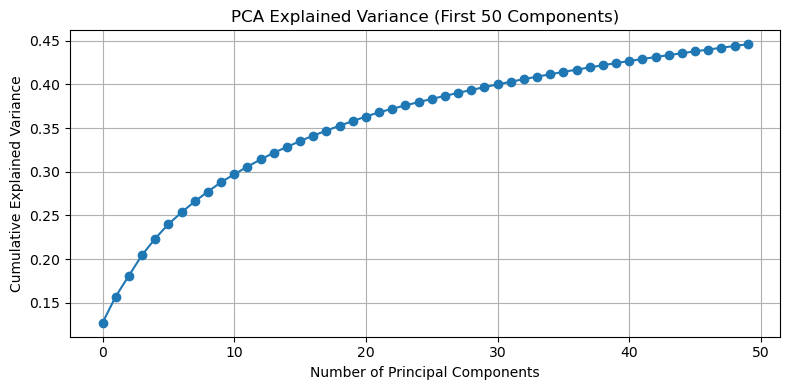

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Plot cumulative explained variance
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_[:50]), marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance (First 50 Components)')
plt.grid(True)
plt.tight_layout()
plt.show()


In [18]:
import pandas as pd
from pathlib import Path

# Load gene expression matrix
file_path = Path(r"C:\Users\jathi\OneDrive\Desktop\PROJECT\GSE19804_series_matrix.txt.txt")

# Read all lines safely
lines = file_path.read_text(errors='ignore').splitlines()

# Detect the header line containing "ID_REF"
for i, line in enumerate(lines):
    if "ID_REF" in line:
        start_line = i
        print(f"✅ Header found at line {i+1}")
        break

# Load into DataFrame from the correct starting point
df = pd.read_csv(file_path, sep="\t", skiprows=start_line, low_memory=False)

# Clean and format the DataFrame
df = df[df.columns.dropna()]  # Drop empty columns
df = df.set_index("ID_REF")   # Set gene IDs as index
df = df.loc[:, df.columns.str.startswith("GSM")]  # Keep sample columns only

# ✅ Print preview
print("\n✅ Gene Expression Matrix (shape):", df.shape)
print(df.head())



✅ Header found at line 64

✅ Gene Expression Matrix (shape): (54676, 120)
           GSM494556  GSM494557  GSM494558  GSM494559  GSM494560  GSM494561  \
ID_REF                                                                        
1007_s_at   11.96280   11.38780   11.19280   11.90360   11.75230   11.04240   
1053_at      7.05652    7.33711    7.26121    7.91211    8.27448    7.60698   
117_at       6.55585    6.96023    7.14488    7.13887    7.72479    8.01441   
121_at       8.43850    8.51636    8.43138    8.67404    8.78145    8.55224   
1255_g_at    3.73169    3.77978    3.99853    3.69171    3.93509    3.54508   

           GSM494562  GSM494563  GSM494564  GSM494565  ...  GSM494666  \
ID_REF                                                 ...              
1007_s_at   10.74160   11.71090   11.46260   11.49050  ...   10.35930   
1053_at      9.80415    8.85862    7.80342    8.43741  ...    7.69447   
117_at       8.88544    7.99740    7.33263   10.54530  ...    7.44120   
121_at 

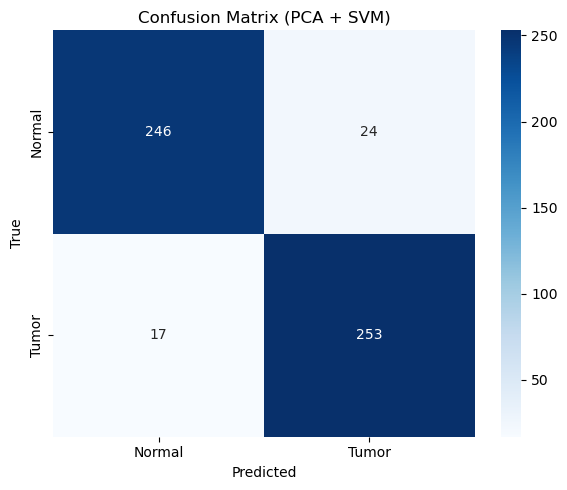

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal", "Tumor"], yticklabels=["Normal", "Tumor"])
plt.title("Confusion Matrix (PCA + SVM)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig("svm_confusion_matrix.png")
plt.show()



🔍 Random Forest Accuracy: 0.8870370370370371

📄 Random Forest Report:
               precision    recall  f1-score   support

           0       0.89      0.89      0.89       270
           1       0.89      0.89      0.89       270

    accuracy                           0.89       540
   macro avg       0.89      0.89      0.89       540
weighted avg       0.89      0.89      0.89       540



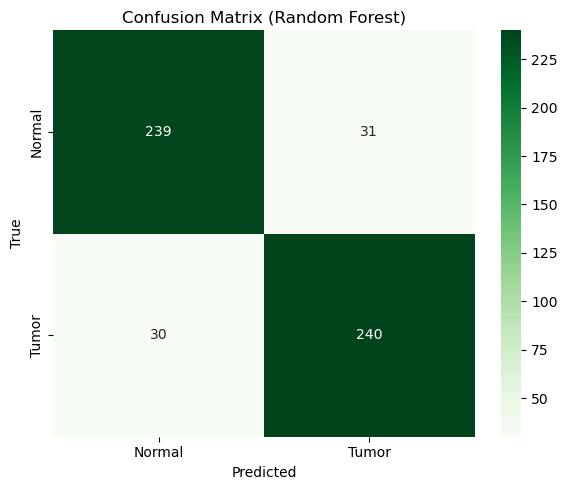

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_scaled, y_train)
rf_pred = rf_clf.predict(X_test_scaled)

print("\n🔍 Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\n📄 Random Forest Report:\n", classification_report(y_test, rf_pred))

# RF Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", xticklabels=["Normal", "Tumor"], yticklabels=["Normal", "Tumor"])
plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig("rf_confusion_matrix.png")
plt.show()


In [20]:
pip install tensorflow


   ---------------------------------------- 0.0/376.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/376.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/376.0 MB 2.8 MB/s eta 0:02:14
   ---------------------------------------- 1.8/376.0 MB 3.2 MB/s eta 0:01:56
   ---------------------------------------- 2.9/376.0 MB 3.7 MB/s eta 0:01:41
   ---------------------------------------- 4.2/376.0 MB 4.3 MB/s eta 0:01:26
    --------------------------------------- 6.3/376.0 MB 5.4 MB/s eta 0:01:09
    --------------------------------------- 6.3/376.0 MB 5.4 MB/s eta 0:01:09
    --------------------------------------- 6.8/376.0 MB 4.2 MB/s eta 0:01:28
    --------------------------------------- 7.3/376.0 MB 4.1 MB/s eta 0:01:30
    --------------------------------------- 7.9/376.0 MB 4.0 MB/s eta 0:01:34
    --------------------------------------- 8.7/376.0 MB 3.9 MB/s eta 0:01:34
   - -------------------------------------- 9.4/376.0 MB 3.9 MB/s eta 0:01:35

In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical

# Encode labels to categorical
y_cat = to_categorical(y)

# Reshape input for CNN (samples, features, 1)
X_reshaped = X.values[..., np.newaxis]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y_cat, test_size=0.25, random_state=42, stratify=y)

# Build CNN model
cnn = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    tf.keras.layers.Conv1D(32, kernel_size=5, activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(2, activation='softmax')  # 2 classes
])

cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn.summary()

# Train
history = cnn.fit(X_train, y_train, epochs=15, batch_size=32, validation_split=0.2)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 54672, 32)      │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 27336, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 27336, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 874752)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    55,984,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,984,514 (213.56 MB)

 Trainable params: 55,984,514 (213.56 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 40s 854ms/step - accuracy: 0.4781 - loss: 272.7932 - val_accuracy: 0.4877 - val_loss: 0.6933
Epoch 2/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 33s 800ms/step - accuracy: 0.4972 - loss: 0.6932 - val_accuracy: 0.4877 - val_loss: 0.6933
Epoch 3/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 20s 470ms/step - accuracy: 0.5128 - loss: 0.6930 - val_accuracy: 0.4877 - val_loss: 0.6933
Epoch 4/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 17s 402ms/step - accuracy: 0.5071 - loss: 0.6931 - val_accuracy: 0.4877 - val_loss: 0.6933
Epoch 5/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 16s 386ms/step - accuracy: 0.5236 - loss: 0.6929 - val_accuracy: 0.4877 - val_loss: 0.6933
Epoch 6/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 16s 401ms/step - accuracy: 0.5149 - loss: 0.6930 - val_accuracy: 0.4877 - val_loss: 0.6933
Epoch 7/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 16s 391ms/step - accuracy: 0.5230 - loss: 0.6929 - val_accuracy: 0.4877 - val_loss: 0.6933
Epoch 8/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 16s 390ms/step - accuracy: 0.4800 - loss: 0.6935 - val_ac

17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step


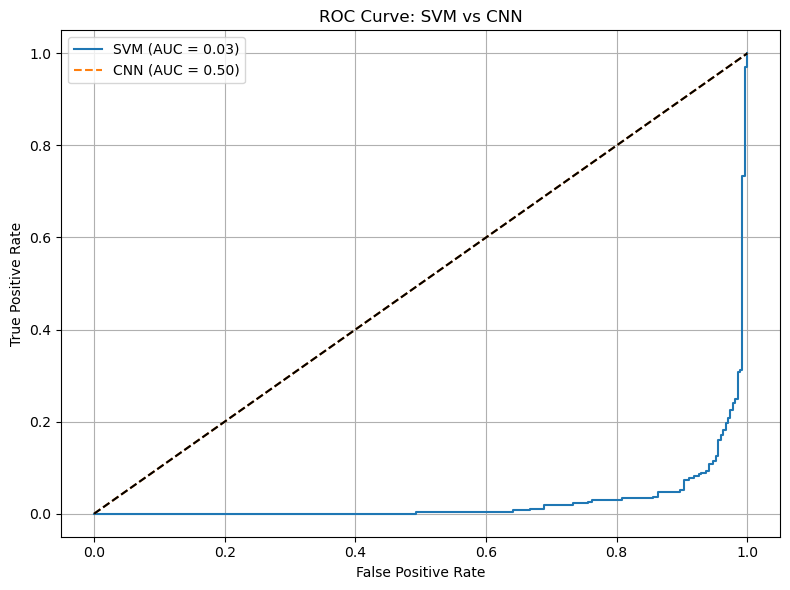

In [24]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import os

# Create directory if it doesn't exist
os.makedirs("PROJECT/results", exist_ok=True)

# Binarize y_test for ROC (assume binary classification)
y_test_bin = label_binarize(y_test, classes=[0, 1])[:, 0]

# --- SVM ---
svm_probs = clf.decision_function(X_test_pca)
fpr_svm, tpr_svm, _ = roc_curve(y_test_bin, svm_probs)
auc_svm = auc(fpr_svm, tpr_svm)

# --- CNN ---
cnn_probs = cnn.predict(X_test)  # shape (n_samples, 2)
fpr_cnn, tpr_cnn, _ = roc_curve(y_test_bin, cnn_probs[:, 1])
auc_cnn = auc(fpr_cnn, tpr_cnn)

# --- Plot ---
plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.2f})")
plt.plot(fpr_cnn, tpr_cnn, linestyle='--', label=f"CNN (AUC = {auc_cnn:.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: SVM vs CNN")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("PROJECT/results/roc_curve_svm_vs_cnn.png", dpi=300)
plt.show()


In [6]:
# Predict using trained SVM
y_pred = clf.predict(X_test_pca)

# Generate and save classification report
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
pd.DataFrame(report).transpose().to_csv("PROJECT/results/paper1/classification_report.csv")


NameError: name 'clf' is not defined